# Accuracy under stratified k-fold cross-validation

`LanguageModelClassifier` honours the estimator contract, so it drops into `cross_val_score`. Each
fold gets a fresh clone fine-tuned from the base model, with no state shared between folds.

Stratified folds keep each fold's class proportions close to the full table's, which matters on
small data. The estimate is the mean fold score with its spread; the percentile interval is a
coarse summary of how much the score moves across splits, not a confidence interval.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import StratifiedKFold, cross_val_score

from sklm import LanguageModelClassifier, LoggingCallback, TrainingConfig

sns.set_theme(style="whitegrid", context="notebook")
SEED = 42

## Data and estimator

`LoggingCallback(log_every="epoch")` keeps the per-fold output to plain log lines.

In [2]:
iris = load_iris(as_frame=True)
X = iris.data.rename(columns=lambda c: c.removesuffix(" (cm)"))
y = iris.target_names[iris.target]

clf = LanguageModelClassifier(
    backend="mlx",
    model="mlx-community/distilgpt2",
    training=TrainingConfig(epochs=60, batch_size=16),
    callback=LoggingCallback(log_every="epoch"),
    random_state=SEED,
)

## Run cross-validation

One fine-tune per fold.

In [3]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
scores = cross_val_score(clf, X, y, cv=cv, scoring="accuracy")

print("per-fold accuracy: " + ", ".join(f"{s:.3f}" for s in scores))
print(f"mean +/- std:      {scores.mean():.3f} +/- {scores.std():.3f}")
lo, hi = np.percentile(scores, 2.5), np.percentile(scores, 97.5)
print(f"95% interval:      [{lo:.3f}, {hi:.3f}]")

18:52:02 ╶ fine-tuning  mlx-community/distilgpt2  108 rows · 60 epochs · bs=16 · lr=auto · seq=auto · aug=2 · val=0.1 · target-weight=1
18:52:09 · step 14/840  loss 3.2562  epoch loss 4.6091±0.9230  last20 4.6091±0.9230  epoch 1.00/60  lr 3.10e-06  2%  eta 396 sec  mem 937.5 MiB↑937.5 MiB
18:52:09 · eval step 14  loss 2.8011  best 2.8011 @ep 1  patience 0/5
18:52:10 · step 28/840  loss 0.7897  epoch loss 1.5965±0.6566  last20 2.2413±1.1518  epoch 2.00/60  lr 6.43e-06  3%  eta 220 sec  mem 1.22 GiB↑1.22 GiB
18:52:10 · eval step 28  loss 0.6117  best 0.6117 @ep 2  patience 0/5
18:52:11 · step 42/840  loss 0.2252  epoch loss 0.3368±0.1125  last20 0.5253±0.3113  epoch 3.00/60  lr 9.76e-06  5%  eta 157 sec  mem 1.22 GiB↑1.22 GiB
18:52:11 · eval step 42  loss 0.2855  best 0.2855 @ep 3  patience 0/5
18:52:11 · step 56/840  loss 0.1695  epoch loss 0.2414±0.0349  last20 0.2468±0.0321  epoch 4.00/60  lr 1.31e-05  7%  eta 125 sec  mem 1.22 GiB↑1.22 GiB
18:52:11 · eval step 56  loss 0.2570  best 0

per-fold accuracy: 0.967, 0.933, 0.900, 1.000, 0.900
mean +/- std:      0.940 +/- 0.039
95% interval:      [0.900, 0.997]


## Spread across folds

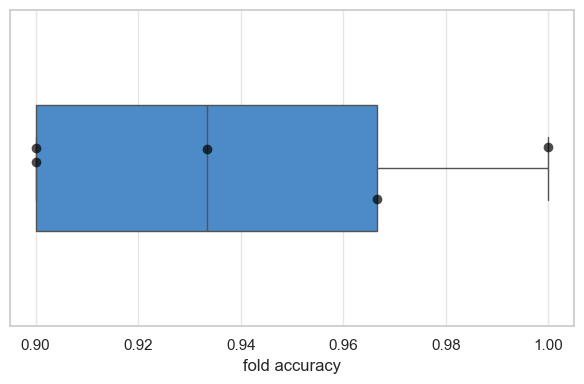

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(x=scores, ax=ax, color="#378add", width=0.4)
sns.stripplot(x=scores, ax=ax, color="black", size=7, alpha=0.7)
ax.set_xlabel("fold accuracy")
plt.tight_layout()
plt.show()